In [5]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("diabetic_data.csv")


In [4]:
del df['readmitted']
del df['encounter_id']
del df['patient_nbr']


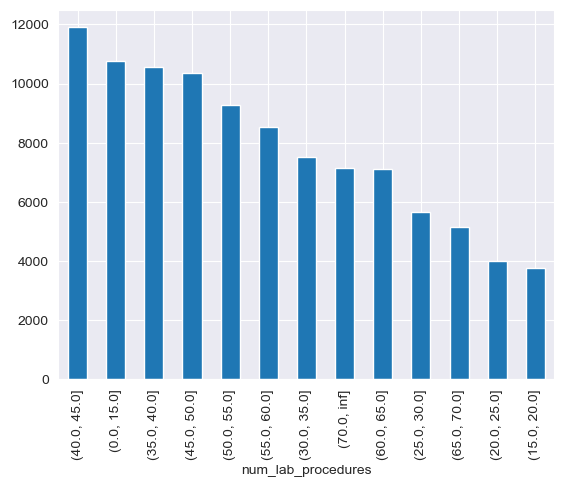

In [6]:

num_lab_procedures_bins = [0, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, np.inf]
pd.cut(df['num_lab_procedures'], num_lab_procedures_bins).value_counts().plot(kind='bar')
df['num_lab_procedures'] = pd.cut(df['num_lab_procedures'], num_lab_procedures_bins)

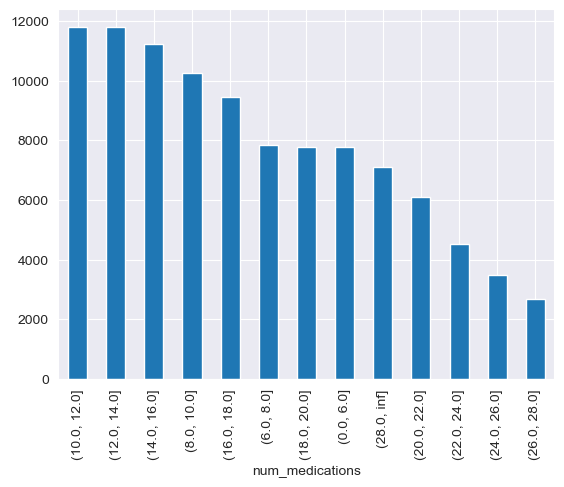

In [7]:
bins_num_medications = [0, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, np.inf]
pd.cut(df['num_medications'], bins=bins_num_medications).value_counts().plot(kind='bar')
df['num_medications'] = pd.cut(df['num_medications'], bins=bins_num_medications)

In [8]:
specialization_to_category = {
    # General Practice
    "Family/GeneralPractice": "General Practice",
    "Hospitalist": "General Practice",
    "Osteopath": "General Practice",
    "OutreachServices": "General Practice",
    "Dentistry": "General Practice",
    "Resident": "General Practice",
    
    # Internal Medicine
    "InternalMedicine": "Internal Medicine",
    "Cardiology": "Internal Medicine",
    "Nephrology": "Internal Medicine",
    "Pulmonology": "Internal Medicine",
    "Psychiatry": "Internal Medicine",
    "Urology": "Internal Medicine",
    "ObstetricsandGynecology": "Internal Medicine",
    "Gastroenterology": "Internal Medicine",
    "Oncology": "Internal Medicine",
    "Pediatrics": "Internal Medicine",
    "Hematology/Oncology": "Internal Medicine",
    "Neurology": "Internal Medicine",
    "Endocrinology": "Internal Medicine",
    "Psychology": "Internal Medicine",
    "InfectiousDiseases": "Internal Medicine",
    "Rheumatology": "Internal Medicine",
    "AllergyandImmunology": "Internal Medicine",
    "Dermatology": "Internal Medicine",
    "SportsMedicine": "Internal Medicine",
    "Perinatology": "Internal Medicine",
    "Neurophysiology": "Internal Medicine",
    "Speech": "Internal Medicine",
    "Pediatrics-Endocrinology": "Internal Medicine",
    "Pediatrics-CriticalCare": "Internal Medicine",
    "Pediatrics-Hematology-Oncology": "Internal Medicine",
    "Pediatrics-InfectiousDiseases": "Internal Medicine",
    "Pediatrics-AllergyandImmunology": "Internal Medicine",
    "Endocrinology-Metabolism": "Internal Medicine",
    "Psychiatry-Child/Adolescent": "Internal Medicine",
    "Psychiatry-Addictive": "Internal Medicine",
    "Cardiology-Pediatric": "Internal Medicine",
    "Pediatrics-Neurology": "Internal Medicine",
    "Pediatrics-EmergencyMedicine": "Internal Medicine",
    "Obsterics&Gynecology-GynecologicOnco": "Internal Medicine",
    "Pediatrics-Pulmonology": "Internal Medicine",
    "Hematology": "Internal Medicine",  # Added

    # Surgery
    "Surgery-General": "Surgery",
    "Orthopedics": "Surgery",
    "Orthopedics-Reconstructive": "Surgery",
    "Surgery-Cardiovascular/Thoracic": "Surgery",
    "Surgery-Vascular": "Surgery",
    "Surgery-Neuro": "Surgery",
    "Surgery-Thoracic": "Surgery",
    "Surgery-Maxillofacial": "Surgery",
    "Surgery-Colon&Rectal": "Surgery",
    "Surgery-Pediatric": "Surgery",
    "Surgery-Plastic": "Surgery",
    "Surgery-Cardiovascular": "Surgery",
    "Surgery-PlasticwithinHeadandNeck": "Surgery",
    "SurgicalSpecialty": "Surgery",
    "Proctology": "Surgery",
    "Surgeon": "Surgery",

    # Missing
    "PhysicianNotFound": "Missing",
    "DCPTEAM": "Missing",
    '?': "Missing",
    
    # Other
    "Emergency/Trauma": "Other",
    "Radiologist": "Other",
    "PhysicalMedicineandRehabilitation": "Other",
    "Pathology": "Other",
    "Obstetrics": "Other",
    "Anesthesiology": "Other",
    "Anesthesiology-Pediatric": "Other",
    "Gynecology": "Other",
    "Otolaryngology": "Other",
    "Radiology": "Other",
    "Podiatry": "Other",
    "Ophthalmology": "Other"
}


In [9]:
df['medical_specialty'] = df['medical_specialty'].apply(lambda x: specialization_to_category[x])

In [10]:
def categorize_icd(icd_code):
    try:
        icd_code = int(icd_code)
        if 390 <= icd_code <= 459 or icd_code == 785:
            return "Circulatory"
        elif 460 <= icd_code <= 519 or icd_code == 786:
            return "Respiratory"
        elif 520 <= icd_code <= 579 or icd_code == 787:
            return "Digestive"
        elif str(icd_code).startswith("250"):
            return "Diabetes"
        elif 800 <= icd_code <= 999:
            return "Injury"
        elif 710 <= icd_code <= 739:
            return "Musculoskeletal"
        elif 580 <= icd_code <= 629 or icd_code == 788:
            return "Genitourinary"
        elif 140 <= icd_code <= 239:
            return "Neoplasms"
        else:
            return "Other"
    except:
        if str(icd_code).startswith("250"):
            return "Diabetes"
        return "Other"



In [11]:
df['diag_1'] = df['diag_1'].apply(categorize_icd)
df['diag_2'] = df['diag_2'].apply(categorize_icd)
df['diag_3'] = df['diag_3'].apply(categorize_icd)

In [13]:
df.nunique()

race                         6
gender                       3
age                         10
weight                      10
admission_type_id            8
discharge_disposition_id    26
admission_source_id         17
time_in_hospital            14
payer_code                  18
medical_specialty            5
num_lab_procedures          13
num_procedures               7
num_medications             13
number_outpatient           39
number_emergency            33
number_inpatient            21
diag_1                       9
diag_2                       9
diag_3                       9
number_diagnoses            16
max_glu_serum                3
A1Cresult                    3
metformin                    4
repaglinide                  4
nateglinide                  4
chlorpropamide               4
glimepiride                  4
acetohexamide                2
glipizide                    4
glyburide                    4
tolbutamide                  2
pioglitazone                 4
rosiglit